# laser_driver_v3 — Differential-Thermometer Uncertainty Budget (ratiometric)

Two ring resonators on one silicon die, separated by a thermal barrier. The beat **Δν = ν_B − ν_A = S·(T_B − T_A)** measures the *local* temperature difference; the quantity of interest is a **ratio that is a property of the material**, acquired over a **τ ≈ 60 s** window. Because it is ratiometric and material-defined, the scale factor S and slow common-mode terms **cancel**, and long-term instrument reproducibility is not required — only **within-window stability** matters.

This notebook:
1. defines all acronyms,
2. keeps the full contributor budget in **hertz** and adds **kelvin** twins (divide by S),
3. folds in **ratiometric cancellation** (slow common terms drop out),
4. adds a **RAM-spectrum input** (the one term that decides the RF in-window floor),
5. computes the **Allan deviation out to 600 s** with the 60 s point marked.

All uncertainties are 1σ on Δν; S = dν/dT ≈ 2 GHz/K.

## 1. Acronyms, symbols, and definitions

### Optical / resonator
| Term | Definition |
|---|---|
| CW | Continuous-wave — constant (non-pulsed) optical output |
| DFB | Distributed-feedback — single-mode semiconductor laser |
| PD | Photodiode |
| InGaAs | Indium gallium arsenide — 1550 nm photodiode material |
| MPD | Monitor photodiode — laser back-facet power monitor |
| TEC | Thermoelectric cooler — Peltier element for temperature control |
| NTC | Negative temperature coefficient — thermistor |
| SiN | Silicon nitride — low-loss waveguide / microring material |
| ULE | Ultra-low-expansion glass — stable reference cavities |
| Q | Quality factor — Q = ν₀ / FWHM |
| FSR | Free spectral range — mode spacing |

### Modulation and locking
| Term | Definition |
|---|---|
| PDH | Pound–Drever–Hall locking |
| RF | Radio frequency |
| FM | Frequency modulation |
| AM | Amplitude modulation |
| RAM | Residual amplitude modulation — unwanted AM accompanying FM/PM |
| EOM | Electro-optic modulator |
| DDS | Direct digital synthesis (AD9833) |
| LO | Local oscillator |
| ACC | Automatic current control |
| APC | Automatic power control |
| DAC / ADC | Digital-to-analog / analog-to-digital converter |
| DMA | Direct memory access |
| β | Modulation index |
| Ω | Modulation frequency |

### Detection and signal chain
| Term | Definition |
|---|---|
| TIA | Transimpedance amplifier |
| AAF | Anti-aliasing filter |
| SNR | Signal-to-noise ratio |
| SFDR | Spurious-free dynamic range |
| BW | Bandwidth |
| PSD | Power spectral density |
| RIN | Relative intensity noise (dBc/Hz) |
| PLL | Phase-locked loop |

### Frequency reference and readout
| Term | Definition |
|---|---|
| FWHM / HWHM | Full / half width at half maximum |
| FFT | Fast Fourier transform |
| TCXO / OCXO | Temperature-compensated / oven-controlled crystal oscillator |
| GPSDO | GPS-disciplined oscillator |
| CMRR | Common-mode rejection ratio |

### Metrology / statistics
| Term | Definition |
|---|---|
| GUM | Guide to the Expression of Uncertainty in Measurement |
| Type A / Type B | Statistical / non-statistical (modelled, judged) uncertainty |
| u_c | Combined standard uncertainty (k = 1) |
| U | Expanded uncertainty, U = k·u_c |
| k | Coverage factor (k = 2 ≈ 95%) |
| R&R | Repeatability and reproducibility |
| Repeatability | Variation under identical conditions, short term |
| Reproducibility | Variation under changed conditions (re-lock, day-to-day) |
| Allan deviation | σ_y(τ) — time-domain frequency stability vs averaging time τ |
| Ratiometric | Observable formed as a ratio, so common scale/offset cancels |

### Symbols
| Symbol | Meaning |
|---|---|
| ν₀ | Optical carrier frequency (≈ 193.4 THz at 1550 nm) |
| Δν | Beat (difference) frequency, ν_B − ν_A |
| S = dν/dT | Ring frequency–temperature sensitivity (≈ 2 GHz/K) |
| ε | Fractional mismatch of the two rings' temperature coefficients |
| ΔT_common | Common (whole-die) absolute temperature excursion |
| ΔT_diff | Differential temperature between rings (the signal channel) |
| τ | Averaging / measurement time (window ≈ 60 s) |
| σ | Standard / Allan deviation |
| f_u | Servo (loop) unity-gain bandwidth |

## 2. Architecture, ratiometric framing, and assumptions

**Differential thermometer.** Δν = S·(T_B − T_A). The local ΔT across the barrier is the *signal*; a whole-die temperature swing moves both rings together and cancels to first order (same-die matching → ε is small).

**Ratiometric, material-defined, 60 s window.** The wanted quantity is a ratio set by the material, so:
- the scale factor S cancels (no absolute calibration needed),
- slow common terms — timebase aging, common-mode thermal leakage (ε·ΔT_common), strain creep, and any RAM *drift* slower than the window — **cancel in the ratio**,
- long-term reproducibility is irrelevant; the figure of merit is the **within-window stability**, i.e. the Allan deviation at **τ ≈ 60 s**.

**What survives** (has content in the ~1/τ_window … loop-BW band): detection noise, residual laser FM, in-band RIN, in-band (flicker) RAM, and the dither carrier-smear residual. Of these, **in-band RAM is the one uncertain term that decides the RF floor** — hence the RAM-spectrum input below.

**"RF"** = MHz analog-derivative lock (true dispersive PDH is unreachable on a Q = 1e5 ≈ 1.9 GHz line). Two framings are kept: the full snapshot budget (Section 3, with a day-to-day reproducibility column shown only for completeness) and the operative within-window / Allan model (Sections 4–5).

In [1]:
import numpy as np
import pandas as pd
C = 299_792_458.0  # m/s

In [2]:
from dataclasses import dataclass

@dataclass
class Params:
    # optical / resonator
    lam: float        = 1550e-9
    Q: float          = 1e5
    dnu_dT: float     = 2.0e9     # S [Hz/K]

    # beat / readout / window
    Delta_nu: float   = 100e6     # nominal beat [Hz]
    fs_span: float    = 20e9      # full-scale measurand range of Delta_nu [Hz]
    tau: float        = 1.0       # snapshot averaging time [s]
    tau_meas: float   = 60.0      # measurement window [s]  <-- the spec point
    tau_max: float    = 600.0     # Allan deviation extent [s]
    ratio_cancel: bool= True      # ratiometric cancellation of slow common terms

    # detection white-FM sqrt-PSD per channel [Hz/sqrt(Hz)]
    det_psd_dither: float = 150.0
    det_psd_rf: float     = 20.0

    # thermal common-mode leakage (cancels in the ratio; shown for completeness)
    eps: float            = 1.0e-4   # same-die coefficient match
    dT_common_rep: float  = 10e-6
    dT_common_repro: float= 1.0e-3
    dT_diff_rep: float    = 10e-9
    dT_diff_repro: float  = 1.0e-6

    # timebase fractional stability
    frac_dither: float = 1e-6
    frac_rf: float     = 1e-8

    # --- RAM spectrum input (KEY) -------------------------------------------
    # in-band (flicker) RAM survives the window and sets the RF floor;
    # slow RAM drift is cancelled by the ratio.
    ram_flicker_dither: float = 20.0   # Hz @1s, flicker (tau^0)  -- survives
    ram_flicker_rf: float     = 20.0   # set 0 if RAM is slower than the window
    ram_drift_dither: float   = 50.0   # Hz @1s, random-walk      -- cancels in ratio
    ram_drift_rf: float       = 50.0

    # snapshot-budget engineering estimates (rep, repro) [Hz]
    laser_fm_dither: tuple = (300.0, 300.0)
    laser_fm_rf:     tuple = (10.0, 10.0)
    smear_dither:    tuple = (50.0, 80.0)
    smear_rf:        tuple = (0.0, 0.0)
    rin_dither:      tuple = (100.0, 400.0)
    rin_rf:          tuple = (8.0, 15.0)
    ram_dither:      tuple = (50.0, 500.0)
    ram_rf:          tuple = (10.0, 50.0)
    strain:          tuple = (30.0, 150.0)

    k: float = 2.0

    @property
    def nu0(self):  return C / self.lam
    @property
    def fwhm(self): return self.nu0 / self.Q
    @property
    def S(self):    return self.dnu_dT


## 3. Full contributor budget — snapshot (Hz, then Kelvin)

Kept for completeness. The reproducibility column is **not** the spec for this ratiometric measurement (see Sections 4–5); it is shown to expose the slow terms that the ratio removes. ε defaults to 1e-4 (same-die match).

In [3]:
def detection_diff(psd, tau): return psd / np.sqrt(tau)
def thermal_gradient(dT, S):     return dT * S
def thermal_mismatch(eps, dTc, S): return eps * dTc * S
def timebase(frac, dv):          return frac * dv

def build_snapshot(p: Params):
    S = p.S
    det_d = detection_diff(p.det_psd_dither, p.tau)
    det_r = detection_diff(p.det_psd_rf,     p.tau)
    g1, g2 = thermal_gradient(p.dT_diff_rep, S), thermal_gradient(p.dT_diff_repro, S)
    m1, m2 = thermal_mismatch(p.eps, p.dT_common_rep, S), thermal_mismatch(p.eps, p.dT_common_repro, S)
    tb_d, tb_r = timebase(p.frac_dither, p.Delta_nu), timebase(p.frac_rf, p.Delta_nu)
    rows = [
        ("Detection / discrimination noise", "A . mod", (det_d, det_d, det_r, det_r)),
        ("Residual laser FM above loop BW",  "A . mod", (*p.laser_fm_dither, *p.laser_fm_rf)),
        ("Carrier-dither smear residual",    "A . mod", (*p.smear_dither, *p.smear_rf)),
        ("RIN -> lock-point pulling",        "B . mod", (*p.rin_dither, *p.rin_rf)),
        ("Line-shape / RAM lock offset",     "B . mod", (*p.ram_dither, *p.ram_rf)),
        ("Thermal - gradient (dT_diff . S)", "B . env", (g1, g2, g1, g2)),
        ("Thermal - mismatch (e.S.dTc)",     "B . env", (m1, m2, m1, m2)),
        ("Strain / vibration (differential)","B . env", (*p.strain, *p.strain)),
        ("Timebase / counter reference",     "B . read",(tb_d, tb_d, tb_r, tb_r)),
    ]
    data = np.array([r[2] for r in rows], float)
    uc = np.sqrt((data**2).sum(0)); U = p.k*uc
    cols = ["Dither - repeat.", "Dither - reprod.", "RF - repeat.", "RF - reprod."]
    return dict(rows=rows, data=data, uc=uc, U=U, cols=cols, S=S, nu0=p.nu0, fwhm=p.fwhm,
                frac_uc=uc/p.nu0, frac_U=U/p.nu0, fs_uc=uc/p.fs_span, fs_U=U/p.fs_span,
                bits=np.log2(p.fs_span/uc))


In [4]:
def fmt_hz(v):
    if isinstance(v, str): return v
    if v == 0: return "—"
    return f"{v:,.0f}"

def fmt_K(v, S):
    if isinstance(v, str): return v
    if v == 0: return "—"
    k = v / S; a = abs(k)
    if a < 1e-6: return f"{k*1e9:.1f} nK"
    if a < 1e-3: return f"{k*1e6:.3g} µK"
    return f"{k*1e3:.3g} mK"

def _style(disp, num, summary_mask):
    sty = disp.style.hide(axis="index").set_properties(subset=num, **{"text-align": "right"})
    sty = sty.apply(lambda r: ["font-weight: 700" if summary_mask[r.name] else "" for _ in r], axis=1)
    return sty

def snapshot_table_hz(info, k=2):
    cols = info["cols"]; ef = lambda x: f"{x:.2e}"
    rows = [[n, t]+list(v) for (n,t,v) in info["rows"]]
    rows += [["Combined standard uncertainty u_c (k=1)", ""]+list(info["uc"]),
             [f"Expanded uncertainty U (k={k:g}, ~95%)", ""]+list(info["U"]),
             ["Fractional u_c  (Δν/ν₀, carrier)", ""]+[ef(x) for x in info["frac_uc"]],
             [f"Fractional u_c  (Δν/FS)", ""]+[ef(x) for x in info["fs_uc"]],
             ["Effective resolution over FS [bits]", ""]+[f"{b:.1f}" for b in info["bits"]]]
    df = pd.DataFrame(rows, columns=["Contributor","Type"]+cols)
    summ = df["Type"].astype(str).str.strip().eq("").tolist()
    disp = df.copy()
    for c in cols: disp[c] = disp[c].map(fmt_hz)
    return _style(disp, cols, summ)

def snapshot_table_K(info, k=2):
    S = info["S"]; cols = info["cols"]
    rows = [[n, t]+[x/S for x in v] for (n,t,v) in info["rows"]]
    rows += [["Combined standard uncertainty u_c (k=1)", ""]+list(info["uc"]/S),
             [f"Expanded uncertainty U (k={k:g}, ~95%)", ""]+list(info["U"]/S)]
    df = pd.DataFrame(rows, columns=["Contributor","Type"]+cols)
    summ = df["Type"].astype(str).str.strip().eq("").tolist()
    disp = df.copy()
    for c in cols: disp[c] = disp[c].map(lambda v: v if isinstance(v,str) else fmt_K(v*S, S))
    return _style(disp, cols, summ)

p = Params()
snap = build_snapshot(p)
print(f"nu0={snap['nu0']:.4e} Hz  FWHM={snap['fwhm']/1e9:.2f} GHz  S={p.S:.2e} Hz/K")
snapshot_table_hz(snap)


nu0=1.9341e+14 Hz  FWHM=1.93 GHz  S=2.00e+09 Hz/K


Contributor,Type,Dither - repeat.,Dither - reprod.,RF - repeat.,RF - reprod.
Detection / discrimination noise,A . mod,150,150,20,20
Residual laser FM above loop BW,A . mod,300,300,10,10
Carrier-dither smear residual,A . mod,50,80,—,—
RIN -> lock-point pulling,B . mod,100,400,8,15
Line-shape / RAM lock offset,B . mod,50,500,10,50
Thermal - gradient (dT_diff . S),B . env,20,"2,000",20,"2,000"
Thermal - mismatch (e.S.dTc),B . env,2,200,2,200
Strain / vibration (differential),B . env,30,150,30,150
Timebase / counter reference,B . read,100,100,1,1
Combined standard uncertainty u_c (k=1),,373,"2,145",44,"2,016"


Kelvin twin of the snapshot budget (each Hz value ÷ S; dimensionless rows omitted):

In [5]:
snapshot_table_K(snap)

Contributor,Type,Dither - repeat.,Dither - reprod.,RF - repeat.,RF - reprod.
Detection / discrimination noise,A . mod,75.0 nK,75.0 nK,10.0 nK,10.0 nK
Residual laser FM above loop BW,A . mod,150.0 nK,150.0 nK,5.0 nK,5.0 nK
Carrier-dither smear residual,A . mod,25.0 nK,40.0 nK,—,—
RIN -> lock-point pulling,B . mod,50.0 nK,200.0 nK,4.0 nK,7.5 nK
Line-shape / RAM lock offset,B . mod,25.0 nK,250.0 nK,5.0 nK,25.0 nK
Thermal - gradient (dT_diff . S),B . env,10.0 nK,1 µK,10.0 nK,1 µK
Thermal - mismatch (e.S.dTc),B . env,1.0 nK,100.0 nK,1.0 nK,100.0 nK
Strain / vibration (differential),B . env,15.0 nK,75.0 nK,15.0 nK,75.0 nK
Timebase / counter reference,B . read,50.0 nK,50.0 nK,0.5 nK,0.5 nK
Combined standard uncertainty u_c (k=1),,186.3 nK,1.07 µK,22.2 nK,1.01 µK


## 4. Ratiometric within-window model (the operative budget)

Each contributor is given an Allan power-law slope μ (σ ∝ τ^μ: white-FM −½, flicker-FM 0, random-walk-FM +½) and a flag for whether the **ratio cancels** it. The combined within-window value is evaluated at **τ_meas = 60 s** using only the surviving terms. The **RAM-spectrum input** sets the in-band (flicker) RAM that survives versus the slow RAM drift that cancels.

In [6]:
def allan_contributors(p: Params):
    # (name, a_dither@1s [Hz], a_rf@1s [Hz], mu, ratio_cancels)
    return [
        ("Detection / discrimination", 150.0, 20.0, -0.5, False),
        ("Residual laser FM floor",     50.0,  6.0,  0.0, False),
        ("RIN in-band",                 60.0,  5.0,  0.0, False),
        ("RAM in-band (flicker)", p.ram_flicker_dither, p.ram_flicker_rf, 0.0, False),
        ("Carrier-dither smear",        50.0,  0.0, -0.5, False),
        ("Timebase short-term",          1.0,  0.1, -0.5, False),
        ("RAM slow drift",        p.ram_drift_dither, p.ram_drift_rf, 0.5, True),
        ("Thermal common-mode leakage", 30.0, 30.0,  0.5, True),
        ("Strain / mount creep",        20.0, 20.0,  0.5, True),
    ]

def sigma_components(p, tau, scheme):
    """Return dict name-> sigma(tau) [Hz] for one scheme; plus cancels flag table."""
    out = {}
    for (n, ad, ar, mu, canc) in allan_contributors(p):
        a = ar if scheme == "rf" else ad
        out[n] = (a * tau**mu, mu, canc)
    return out

def sigma_allan(p, taus, scheme, ratio=True):
    taus = np.atleast_1d(np.asarray(taus, float)); tot = np.zeros_like(taus)
    for (n, ad, ar, mu, canc) in allan_contributors(p):
        if ratio and canc: continue
        a = ar if scheme == "rf" else ad
        tot += (a * taus**mu)**2
    return np.sqrt(tot)


In [7]:
def within_window_table(p: Params, hz=True):
    tau = p.tau_meas; S = p.S
    comp_d = sigma_components(p, tau, "dither")
    comp_r = sigma_components(p, tau, "rf")
    rows = []
    for (n, ad, ar, mu, canc) in allan_contributors(p):
        sd = comp_d[n][0]; sr = comp_r[n][0]
        rows.append([n, "cancels" if canc else "kept", sd, sr])
    df = pd.DataFrame(rows, columns=["Contributor", "In ratio", f"Dither @ {tau:g}s", f"RF @ {tau:g}s"])
    uc_d = sigma_allan(p, tau, "dither", ratio=p.ratio_cancel)[0]
    uc_r = sigma_allan(p, tau, "rf",     ratio=p.ratio_cancel)[0]
    df.loc[len(df)] = [f"Combined (ratio={p.ratio_cancel}) @ {tau:g}s", "", uc_d, uc_r]
    numc = [f"Dither @ {tau:g}s", f"RF @ {tau:g}s"]
    summ = (df["In ratio"].astype(str).str.strip().eq("")).tolist()
    disp = df.copy()
    fmt = (lambda v: fmt_hz(v)) if hz else (lambda v: fmt_K(v, S))
    for c in numc: disp[c] = disp[c].map(lambda v: v if isinstance(v,str) else fmt(v))
    sty = disp.style.hide(axis="index").set_properties(subset=numc, **{"text-align":"right"})
    # grey the cancelled rows, bold the combined row
    def rowstyle(r):
        if summ[r.name]:  return ["font-weight: 700" for _ in r]
        if str(df.iloc[r.name]["In ratio"]) == "cancels":
            return ["color: #999; text-decoration: line-through" for _ in r]
        return ["" for _ in r]
    return sty.apply(rowstyle, axis=1), (uc_d, uc_r)

print("WITHIN-WINDOW BUDGET (Hz) at tau_meas =", p.tau_meas, "s")
sty_hz, (ucd, ucr) = within_window_table(p, hz=True)
print(f"Combined: dither {ucd:.0f} Hz ({ucd/p.S*1e9:.1f} nK)   RF {ucr:.0f} Hz ({ucr/p.S*1e9:.1f} nK)")
sty_hz


WITHIN-WINDOW BUDGET (Hz) at tau_meas = 60.0 s
Combined: dither 83 Hz (41.6 nK)   RF 22 Hz (10.8 nK)


Contributor,In ratio,Dither @ 60s,RF @ 60s
Detection / discrimination,kept,19,3
Residual laser FM floor,kept,50,6
RIN in-band,kept,60,5
RAM in-band (flicker),kept,20,20
Carrier-dither smear,kept,6,—
Timebase short-term,kept,0,0
RAM slow drift,cancels,387,387
Thermal common-mode leakage,cancels,232,232
Strain / mount creep,cancels,155,155
Combined (ratio=True) @ 60s,,83,22


Kelvin twin (within-window):

In [8]:
within_window_table(p, hz=False)[0]

Contributor,In ratio,Dither @ 60s,RF @ 60s
Detection / discrimination,kept,9.7 nK,1.3 nK
Residual laser FM floor,kept,25.0 nK,3.0 nK
RIN in-band,kept,30.0 nK,2.5 nK
RAM in-band (flicker),kept,10.0 nK,10.0 nK
Carrier-dither smear,kept,3.2 nK,—
Timebase short-term,kept,0.1 nK,0.0 nK
RAM slow drift,cancels,193.6 nK,193.6 nK
Thermal common-mode leakage,cancels,116.2 nK,116.2 nK
Strain / mount creep,cancels,77.5 nK,77.5 nK
Combined (ratio=True) @ 60s,,41.6 nK,10.8 nK


### 4b. σ at key averaging times (Hz and Kelvin)

In [9]:
def sigma_vs_tau_table(p: Params, taus=(1, 10, 60, 100, 600)):
    S = p.S
    rec = []
    for t in taus:
        d = sigma_allan(p, t, "dither", p.ratio_cancel)[0]
        r = sigma_allan(p, t, "rf",     p.ratio_cancel)[0]
        rec.append((t, d, r))
    df = pd.DataFrame(rec, columns=["tau [s]", "Dither", "RF"])
    df_hz = df.copy()
    df_hz["Dither"] = df_hz["Dither"].map(lambda v: f"{v:,.1f} Hz")
    df_hz["RF"]     = df_hz["RF"].map(lambda v: f"{v:,.1f} Hz")
    df_K = df.copy()
    df_K["Dither"]  = df_K["Dither"].map(lambda v: fmt_K(v, S))
    df_K["RF"]      = df_K["RF"].map(lambda v: fmt_K(v, S))
    df_K = df_K.rename(columns={"Dither":"Dither (ΔT)", "RF":"RF (ΔT)"})
    return df_hz, df_K

t_hz, t_K = sigma_vs_tau_table(p)
display(t_hz.style.hide(axis="index"))
display(t_K.style.hide(axis="index"))


tau [s],Dither,RF
1,177.5 Hz,29.3 Hz
10,94.9 Hz,22.4 Hz
60,83.2 Hz,21.6 Hz
100,82.2 Hz,21.6 Hz
600,80.9 Hz,21.5 Hz


tau [s],Dither (ΔT),RF (ΔT)
1,88.7 nK,14.7 nK
10,47.4 nK,11.2 nK
60,41.6 nK,10.8 nK
100,41.1 nK,10.8 nK
600,40.4 nK,10.7 nK


## 5. Allan deviation out to 600 s

Solid = ratiometric (slow common terms cancelled); dashed = without ratio cancellation, showing the slow terms re-entering as a random-walk upturn. The 60 s measurement point is marked. Right axis is the equivalent differential temperature.

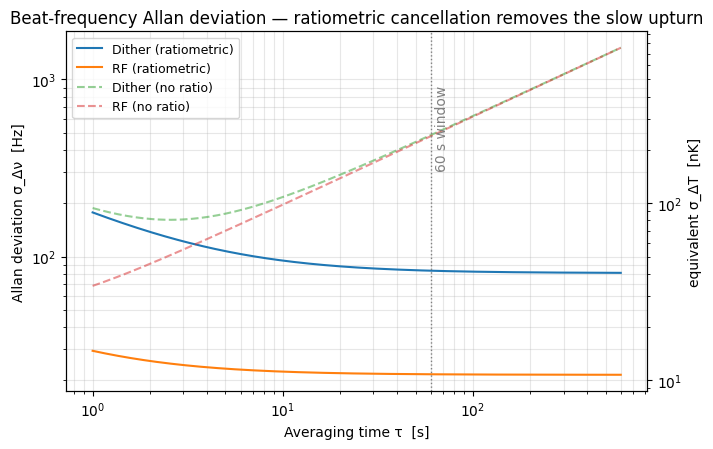

In [10]:
try:
    import matplotlib.pyplot as plt
    taus = np.logspace(0, np.log10(p.tau_max), 250)
    sd_r = sigma_allan(p, taus, "dither", True)
    sr_r = sigma_allan(p, taus, "rf",     True)
    sd_n = sigma_allan(p, taus, "dither", False)
    sr_n = sigma_allan(p, taus, "rf",     False)
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.loglog(taus, sd_r, label="Dither (ratiometric)")
    ax.loglog(taus, sr_r, label="RF (ratiometric)")
    ax.loglog(taus, sd_n, "--", alpha=0.5, label="Dither (no ratio)")
    ax.loglog(taus, sr_n, "--", alpha=0.5, label="RF (no ratio)")
    ax.axvline(p.tau_meas, color="gray", ls=":", lw=1)
    ax.text(p.tau_meas*1.05, ax.get_ylim()[1]*0.5, f"{p.tau_meas:g} s window", color="gray", rotation=90, va="top")
    ax.set_xlabel("Averaging time τ  [s]")
    ax.set_ylabel("Allan deviation σ_Δν  [Hz]")
    ax.set_title("Beat-frequency Allan deviation — ratiometric cancellation removes the slow upturn")
    ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=9)
    ax2 = ax.twinx(); ax2.set_yscale("log")
    ax2.set_ylim(np.array(ax.get_ylim())/p.S*1e9)   # nK
    ax2.set_ylabel("equivalent σ_ΔT  [nK]")
    plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib not installed - skip the plot.")


## 6. Interactive sliders (Colab-ready) — incl. RAM spectrum

Enables Colab's widget manager; installs ipywidgets only if missing. Drag `RAM flicker (RF)` between 0 and 20 Hz to see the RF within-window floor move between the RAM-cancels and RAM-survives cases.

In [11]:
try:
    from google.colab import output as _co
    _co.enable_custom_widget_manager()
except Exception:
    pass
try:
    import ipywidgets as W
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as W
from IPython.display import display

def interactive(ram_flicker_rf=20.0, ram_flicker_dither=20.0,
                det_psd_rf=20.0, eps_log=-4.0, tau_meas=60.0, ratio_cancel=True):
    p = Params(ram_flicker_rf=ram_flicker_rf, ram_flicker_dither=ram_flicker_dither,
               det_psd_rf=det_psd_rf, eps=10**eps_log, tau_meas=tau_meas,
               ratio_cancel=ratio_cancel)
    sty, (ucd, ucr) = within_window_table(p, hz=True)
    print(f"@ {tau_meas:g}s  |  dither {ucd:6.1f} Hz = {ucd/p.S*1e9:6.1f} nK    "
          f"RF {ucr:6.1f} Hz = {ucr/p.S*1e9:5.1f} nK   (ratio={ratio_cancel})")
    display(sty)

W.interact(interactive,
           ram_flicker_rf=W.FloatSlider(value=20, min=0, max=60, step=1, description="RAM flick RF"),
           ram_flicker_dither=W.FloatSlider(value=20, min=0, max=60, step=1, description="RAM flick dith"),
           det_psd_rf=W.FloatSlider(value=20, min=2, max=200, step=2, description="RF det PSD"),
           eps_log=W.FloatSlider(value=-4, min=-5, max=-2, step=0.25, description="log10(eps)"),
           tau_meas=W.FloatLogSlider(value=60, base=10, min=0, max=2.78, description="tau [s]"),
           ratio_cancel=W.Checkbox(value=True, description="ratio cancel"));


interactive(children=(FloatSlider(value=20.0, description='RAM flick RF', max=60.0, step=1.0), FloatSlider(val…

### 6b. No-widget what-if (always works)

In [12]:
def recompute(**ov):
    p = Params(**ov)
    sty, (ucd, ucr) = within_window_table(p, hz=True)
    print(f"@ {p.tau_meas:g}s  dither {ucd:.1f} Hz = {ucd/p.S*1e9:.1f} nK   RF {ucr:.1f} Hz = {ucr/p.S*1e9:.1f} nK")
    return sty

recompute(ram_flicker_rf=0.0)   # RAM slower than window -> cancels -> best-case RF


@ 60s  dither 83.2 Hz = 41.6 nK   RF 8.2 Hz = 4.1 nK


Contributor,In ratio,Dither @ 60s,RF @ 60s
Detection / discrimination,kept,19,3
Residual laser FM floor,kept,50,6
RIN in-band,kept,60,5
RAM in-band (flicker),kept,20,—
Carrier-dither smear,kept,6,—
Timebase short-term,kept,0,0
RAM slow drift,cancels,387,387
Thermal common-mode leakage,cancels,232,232
Strain / mount creep,cancels,155,155
Combined (ratio=True) @ 60s,,83,8


## 7. Clean tables (final) — Hz and Kelvin, with Markdown export

Within-window budget at τ = 60 s (the operative result), as styled tables and as Markdown for the project docs.

In [13]:
def to_markdown(df_disp, num_cols):
    cols = list(df_disp.columns)
    sep = "|" + "|".join([" ---: " if c in num_cols else " --- " for c in cols]) + "|"
    out = ["| " + " | ".join(cols) + " |", sep]
    for _, row in df_disp.iterrows():
        out.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join(out)

p = Params()
print("=== Within-window budget @ 60 s — Hertz ===")
display(within_window_table(p, hz=True)[0])
print("=== Within-window budget @ 60 s — Kelvin ===")
display(within_window_table(p, hz=False)[0])

# Markdown export of the sigma-vs-tau summary (Hz + K)
t_hz, t_K = sigma_vs_tau_table(p)
print("\nσ_Δν vs τ (Hz):\n");  print(to_markdown(t_hz, ["Dither","RF"]))
print("\nσ_ΔT vs τ (Kelvin):\n"); print(to_markdown(t_K, ["Dither (ΔT)","RF (ΔT)"]))


=== Within-window budget @ 60 s — Hertz ===


Contributor,In ratio,Dither @ 60s,RF @ 60s
Detection / discrimination,kept,19,3
Residual laser FM floor,kept,50,6
RIN in-band,kept,60,5
RAM in-band (flicker),kept,20,20
Carrier-dither smear,kept,6,—
Timebase short-term,kept,0,0
RAM slow drift,cancels,387,387
Thermal common-mode leakage,cancels,232,232
Strain / mount creep,cancels,155,155
Combined (ratio=True) @ 60s,,83,22


=== Within-window budget @ 60 s — Kelvin ===


Contributor,In ratio,Dither @ 60s,RF @ 60s
Detection / discrimination,kept,9.7 nK,1.3 nK
Residual laser FM floor,kept,25.0 nK,3.0 nK
RIN in-band,kept,30.0 nK,2.5 nK
RAM in-band (flicker),kept,10.0 nK,10.0 nK
Carrier-dither smear,kept,3.2 nK,—
Timebase short-term,kept,0.1 nK,0.0 nK
RAM slow drift,cancels,193.6 nK,193.6 nK
Thermal common-mode leakage,cancels,116.2 nK,116.2 nK
Strain / mount creep,cancels,77.5 nK,77.5 nK
Combined (ratio=True) @ 60s,,41.6 nK,10.8 nK



σ_Δν vs τ (Hz):

| tau [s] | Dither | RF |
| --- | ---: | ---: |
| 1 | 177.5 Hz | 29.3 Hz |
| 10 | 94.9 Hz | 22.4 Hz |
| 60 | 83.2 Hz | 21.6 Hz |
| 100 | 82.2 Hz | 21.6 Hz |
| 600 | 80.9 Hz | 21.5 Hz |

σ_ΔT vs τ (Kelvin):

| tau [s] | Dither (ΔT) | RF (ΔT) |
| --- | ---: | ---: |
| 1 | 88.7 nK | 14.7 nK |
| 10 | 47.4 nK | 11.2 nK |
| 60 | 41.6 nK | 10.8 nK |
| 100 | 41.1 nK | 10.8 nK |
| 600 | 40.4 nK | 10.7 nK |


---
*Operative result: with ratiometric cancellation the spec is σ at τ ≈ 60 s. RF reaches the low-nanokelvin range; whether it lands near ~4 nK or ~11 nK is decided by the in-band RAM term — measure the RAM spectrum early. Slow common terms (timebase aging, ε·ΔT_common, strain creep, slow RAM drift) cancel in the ratio and do not enter the result.*